# <span style="color:blue"><b>PROYECTO FINAL</b></span>

# <span style="color:blue"><b>SISTEMA DE AUTENTICACIÓN MULTIPARTE DE CARTERAS</b></span>


#Integrantes
### ● Jesus Campos
### ● Marco Barrera



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive

MyDrive


In [3]:
!ls /content/drive/MyDrive/PI_II

 Autenticacion_Carteras__Metricas_v03.ipynb
 Autenticacion_Carteras__Metricas_v07.ipynb
 Autenticacion_Carteras__Metricas_v08.ipynb
 Chanel_Parts_00.zip
 Chanel_Parts.zip
 chanel.zip
 Ch_parts_v2
 DATASET
 DATASET.zip
'Guía Experta: Autenticación de Carteras Chanel.gdoc'
 history_mobile.pkl
 history_resnet.pkl
 modelo_autenticacion.h5
 modelo_autenticacion.keras
 modelo_logo_turnlock_balanceado.keras
 modelo_logo_turnlock_corregido.keras
 modelo_logo_turnlock.keras
 modelo_mobilenetv2_logo_turnlock.keras
 modelo_resnet50_logo_turnlock.keras
 pipeline_autenticacion.docx
 pipeline_autenticacion_v2.docx
 Proyecto_Pipeline_COMPLETO.docx
 Proyecto_Pipeline.docx
 Proyecto_Pipeline_final.docx
 VERSION_01
 VERSION_02
 yolo_chanel.ipynb


In [4]:
import shutil
import os

SRC_ZIP = "/content/drive/MyDrive/PI_II/chanel.zip"
DST_ZIP = "/content/chanel.zip"

print("Copiando ZIP a disco local...")
shutil.copy2(SRC_ZIP, DST_ZIP)
print("ZIP copiado a /content/")


Copiando ZIP a disco local...
ZIP copiado a /content/


In [5]:
import zipfile

with zipfile.ZipFile("/content/chanel.zip", "r") as z:
    for name in z.namelist()[:30]:
        print(name)

chanel/
chanel/fake/
chanel/fake/bag---2.55/
chanel/fake/bag---2.55/0104/
chanel/fake/bag---2.55/0104/0104_1.jpg
chanel/fake/bag---2.55/0104/0104_2.jpg
chanel/fake/bag---2.55/0104/0104_3.jpg
chanel/fake/bag---2.55/0104/0104_4.jpg
chanel/fake/bag---2.55/0105/
chanel/fake/bag---2.55/0105/0105_1.jpg
chanel/fake/bag---2.55/0105/0105_2.jpg
chanel/fake/bag---2.55/0105/0105_3.jpg
chanel/fake/bag---2.55/0105/0105_4.jpg
chanel/fake/bag---2.55/0105/0105_5.jpg
chanel/fake/bag---2.55/0106/
chanel/fake/bag---2.55/0106/0106_1.jpg
chanel/fake/bag---2.55/0106/0106_2.jpg
chanel/fake/bag---2.55/0107/
chanel/fake/bag---2.55/0107/0107_1.jpg
chanel/fake/bag---2.55/0107/0107_2.jpg
chanel/fake/bag---2.55/0107/0107_3.jpg
chanel/fake/bag---2.55/0107/0107_4.jpg
chanel/fake/bag---2.55/0107/0107_5.jpg
chanel/fake/bag---2.55/0107/0107_6.jpg
chanel/fake/bag---2.55/0107/0107_7.jpg
chanel/fake/bag---2.55/0107/0107_8.jpg
chanel/fake/bag---2.55/0107/0107_9.jpg
chanel/fake/bag---2.55/0108/
chanel/fake/bag---2.55/0108/01

In [6]:
import zipfile

EXTRACT_DIR = "/content/data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Descomprimiendo ZIP en /content/data...")
with zipfile.ZipFile(DST_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset descomprimido en /content/data")

Descomprimiendo ZIP en /content/data...
Dataset descomprimido en /content/data


In [7]:
!ls /content/data/chanel

fake  genuine


### <span style="color:#800020"><b>Entrenamiento del Modelo para Autenticación de Carteras</b></span>

Se entrena un modelo de clasificación binaria para distinguir entre carteras genuinas y falsas usando EfficientNetB0, MobileNetV2 y ResNet50.
Se utiliza validación y early stopping para mejorar la generalización y evitar sobreajuste.

In [8]:
import zipfile, os, shutil

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")
print(os.listdir(DEST_DIR))

Dataset descomprimido
['genuine', 'fake']


In [9]:
import zipfile
import os
import shutil
import pandas as pd

ZIP_PATH = "/content/drive/MyDrive/PI_II/Chanel_Parts.zip"
DEST_DIR = "/content/Chanel_Parts"

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descomprimido")

# extensiones válidas de imágenes
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

data = []

for root, dirs, files in os.walk(DEST_DIR):
    img_count = sum(1 for f in files if f.lower().endswith(IMG_EXT))

    if img_count > 0:
        rel_path = os.path.relpath(root, DEST_DIR)
        data.append([rel_path, img_count])

df = pd.DataFrame(data, columns=["Carpeta", "Cantidad_Imagenes"])

# ordenar por cantidad
df = df.sort_values(by="Cantidad_Imagenes", ascending=False)

# mostrar tabla
print(df.to_string(index=False))

# total general
print("\nTOTAL DE IMÁGENES:", df["Cantidad_Imagenes"].sum())

Dataset descomprimido
           Carpeta  Cantidad_Imagenes
 genuine/bag---boy               1632
genuine/bag---2.55                414
    fake/bag---boy                200
   fake/bag---2.55                200

TOTAL DE IMÁGENES: 2446


### <span style="color:#800020"><b>Modelo de Partes EfficientNetB3</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura EfficientNetB3 mediante transferencia de aprendizaje

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (300,300)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300,300,3)
)

base_model.trainable = False

model = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total: {total_time:.2f} segundos")
        print(f"Tiempo total: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[time_callback]
)

model.save("/content/drive/MyDrive/PI_II/modelo_EfficientNetB3.keras")

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.7291 - loss: 0.6851
Tiempo época 1: 131.74 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 132s 619ms/step - accuracy: 0.7016 - loss: 0.6947 - val_accuracy: 0.6953 - val_loss: 0.6173
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6733 - loss: 0.6423
Tiempo época 2: 2.95 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6863 - loss: 0.6483 - val_accuracy: 0.7382 - val_loss: 0.5944
Epoch 3/20
122/123 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7027 - loss: 0.5914
Tiempo época 3: 2.93 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7174 - loss: 0.5903 - val_accuracy: 0.7894 - val_loss: 0.5549
Epo

### <span style="color:#800020"><b>Modelo de Partes MobileNetV3</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura MobileNetV3 mediante transferencia de aprendizaje

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_mobilev3 = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_mobilev3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total de entrenamiento: {total_time:.2f} segundos")
        print(f"Tiempo total de entrenamiento: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mobilev3 = model_mobilev3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, time_callback]
)

print("Mejor Val Accuracy MobileNetV3Large:",
      max(history_mobilev3.history["val_accuracy"]))

print("Mejor Val Loss MobileNetV3Large:",
      min(history_mobilev3.history["val_loss"]))

model_mobilev3.save(
    "/content/drive/MyDrive/PI_II/modelo_mobilenetv3_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_mobilev3.pkl", "wb") as f:
    pickle.dump(history_mobilev3.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6861 - loss: 0.9573
Tiempo época 1: 50.25 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 50s 254ms/step - accuracy: 0.6219 - loss: 0.9665 - val_accuracy: 0.5910 - val_loss: 0.6783
Epoch 2/20
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5806 - loss: 0.7995
Tiempo época 2: 1.65 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5856 - loss: 0.8142 - val_accuracy: 0.6135 - val_loss: 0.6489
Epoch 3/20
120/123 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5766 - loss: 0.7109
Tiempo época 3: 1.63 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5963 - loss: 0.7178 - val_accuracy: 0.6830 - val_loss: 0.5955
Epoch

### <span style="color:#800020"><b>Modelo de Partes ResNet50</b></span>

modelo de autenticación basado en componentes específicos de carteras Chanel. El modelo fue entrenado utilizando imágenes de las partes logo y turnlock de los modelos Chanel 2.55 y Boy, clasificándolas en las categorías genuine y fake. Para el entrenamiento se utilizó la arquitectura ResNet50 mediante transferencia de aprendizaje

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pickle
import time

DATA_DIR = "/content/Chanel_Parts"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())

class_weights = dict(enumerate(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)))

print(class_weights)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_resnet = models.Sequential([
    layers.RandomFlip("horizontal"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

class TimeHistory(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"\nTiempo época {epoch+1}: {elapsed:.2f} segundos")

    def on_train_end(self, logs=None):
        total_time = time.time() - self.train_start

        print("\nTiempo por época:")
        for i, t in enumerate(self.epoch_times):
            print(f"Época {i+1}: {t:.2f} segundos")

        print(f"\nTiempo total de entrenamiento: {total_time:.2f} segundos")
        print(f"Tiempo total de entrenamiento: {total_time/60:.2f} minutos")

time_callback = TimeHistory()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, time_callback]
)

print("Mejor Val Accuracy ResNet50:",
      max(history_resnet.history["val_accuracy"]))

print("Mejor Val Loss ResNet50:",
      min(history_resnet.history["val_loss"]))

model_resnet.save(
    "/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras"
)

with open("/content/drive/MyDrive/PI_II/history_resnet.pkl", "wb") as f:
    pickle.dump(history_resnet.history, f)

Found 2446 files belonging to 2 classes.
Using 1957 files for training.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.
['fake', 'genuine']
{0: np.float64(3.086750788643533), 1: np.float64(0.5966463414634147)}
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5782 - loss: 0.7319
Tiempo época 1: 24.75 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.6127 - loss: 0.7000 - val_accuracy: 0.7198 - val_loss: 0.5738
Epoch 2/20
120/123 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7176 - loss: 0.5752
Tiempo época 2: 2.15 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7195 - loss: 0.5661 - val_accuracy: 0.7975 - val_loss: 0.4997
Epoch 3/20
122/123 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7486 - loss: 0.4886
Tiempo época 3: 2.12 segundos
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7619 - loss: 0.5059 - val_accuracy: 0.8344 - val_loss: 0.4340
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - ac

In [18]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import pandas as pd

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

model_eff = load_model("/content/drive/MyDrive/PI_II/modelo_EfficientNetB3.keras")
model_mobile = load_model("/content/drive/MyDrive/PI_II/modelo_mobilenetv3_logo_turnlock.keras")
model_resnet = load_model("/content/drive/MyDrive/PI_II/modelo_resnet50_logo_turnlock.keras")

loss_eff, acc_eff = model_eff.evaluate(val_ds_300, verbose=0)
loss_mobile, acc_mobile = model_mobile.evaluate(val_ds_224, verbose=0)
loss_resnet, acc_resnet = model_resnet.evaluate(val_ds_224, verbose=0)

resultados = pd.DataFrame({
    "Modelo": ["ResNet50", "EfficientNetB3", "MobileNetV3"],
    "Accuracy": [acc_resnet, acc_eff, acc_mobile],
    "Loss": [loss_resnet, loss_eff, loss_mobile]
})

resultados["Accuracy (%)"] = resultados["Accuracy"] * 100
resultados["Error (%)"] = 100 - resultados["Accuracy (%)"]

resultados = resultados.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

resultados["Ranking"] = ["🥇", "🥈", "🥉"]

display(resultados)

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


,Modelo,Accuracy,Loss,Accuracy (%),Error (%),Ranking
0,ResNet50,0.932515,0.219140,93.251532,6.748468,🥇
1,MobileNetV3,0.912065,0.270404,91.206545,8.793455,🥈
2,EfficientNetB3,0.883436,0.343516,88.343561,11.656439,🥉


In [20]:
print("history" in globals())
print("history_resnet" in globals())
print("history_mobilev3" in globals())

True
True
True


**Precisión de Entrenamiento y Validación**

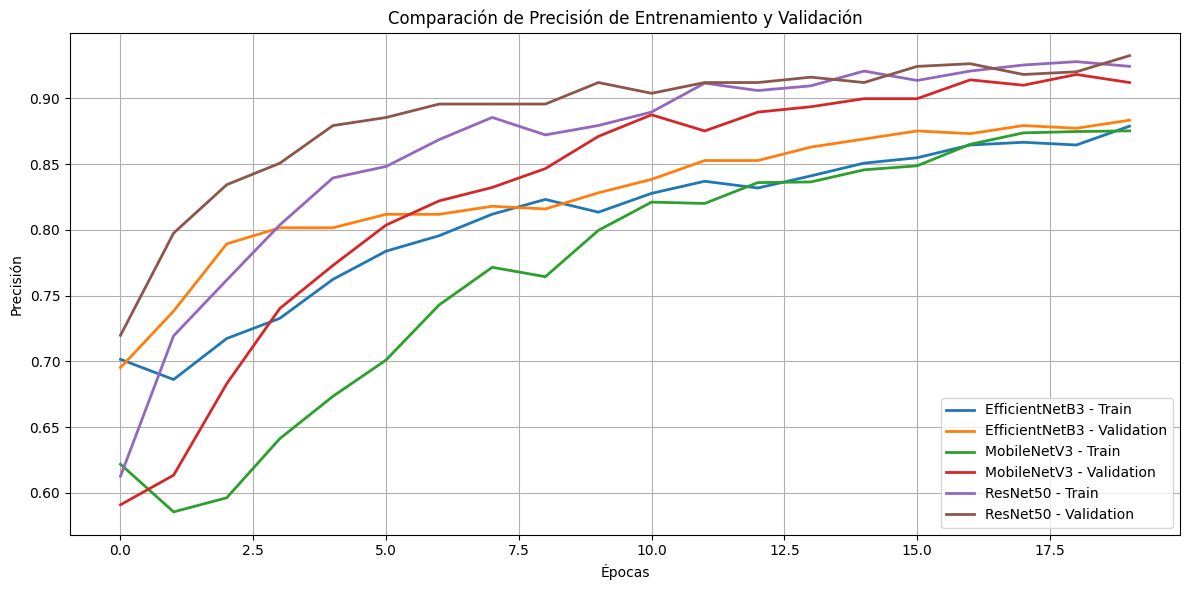

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['accuracy'],
         label='EfficientNetB3 - Train',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='EfficientNetB3 - Validation',
         linewidth=2)

plt.plot(history_mobilev3.history['accuracy'],
         label='MobileNetV3 - Train',
         linewidth=2)

plt.plot(history_mobilev3.history['val_accuracy'],
         label='MobileNetV3 - Validation',
         linewidth=2)

plt.plot(history_resnet.history['accuracy'],
         label='ResNet50 - Train',
         linewidth=2)

plt.plot(history_resnet.history['val_accuracy'],
         label='ResNet50 - Validation',
         linewidth=2)

plt.title('Comparación de Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

**Loss de Entrenamiento vs Validación**

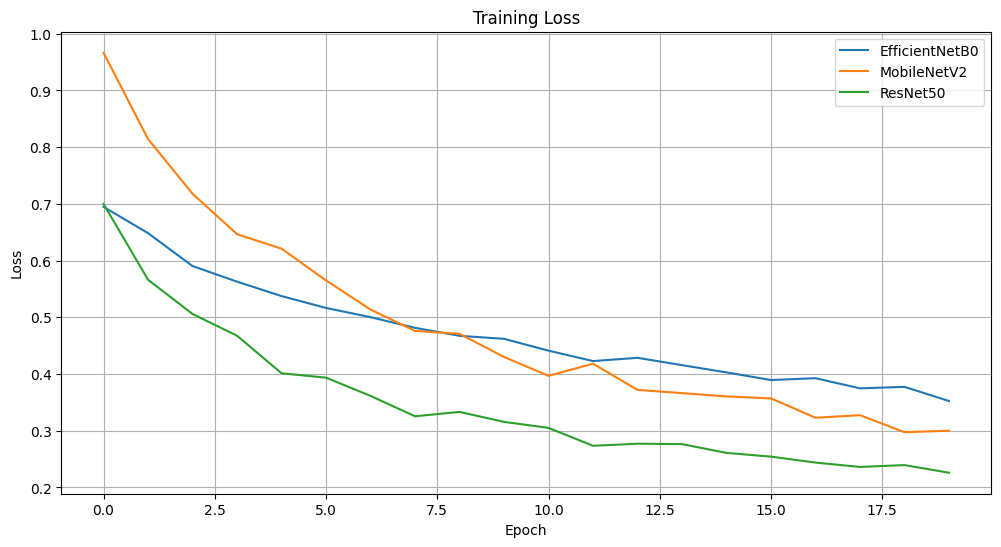

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history['loss'], label='EfficientNetB0')
plt.plot(history_mobilev3.history['loss'], label='MobileNetV2')
plt.plot(history_resnet.history['loss'], label='ResNet50')

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import pandas as pd

df_metricas = pd.DataFrame({
    "Modelo": ["EfficientNetB3", "MobileNetV3", "ResNet50"],
    "Mejor Val Accuracy": [
        max(history.history["val_accuracy"]),
        max(history_mobilev3.history["val_accuracy"]),
        max(history_resnet.history["val_accuracy"])
    ],
    "Mejor Val Loss": [
        min(history.history["val_loss"]),
        min(history_mobilev3.history["val_loss"]),
        min(history_resnet.history["val_loss"])
    ],
    "Épocas entrenadas": [
        len(history.history["accuracy"]),
        len(history_mobilev3.history["accuracy"]),
        len(history_resnet.history["accuracy"])
    ]
})

df_metricas["Accuracy (%)"] = df_metricas["Mejor Val Accuracy"] * 100
df_metricas["Error (%)"] = 100 - df_metricas["Accuracy (%)"]

df_metricas = df_metricas.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

df_metricas["Ranking"] = ["🥇", "🥈", "🥉"]

display(df_metricas)

,Modelo,Mejor Val Accuracy,Mejor Val Loss,Épocas entrenadas,Accuracy (%),Error (%),Ranking
0,ResNet50,0.932515,0.219140,20,93.251532,6.748468,🥇
1,MobileNetV3,0.918200,0.270405,20,91.820043,8.179957,🥈
2,EfficientNetB3,0.883436,0.343516,20,88.343561,11.656439,🥉


**# Comparativa de los 3 Modelos**

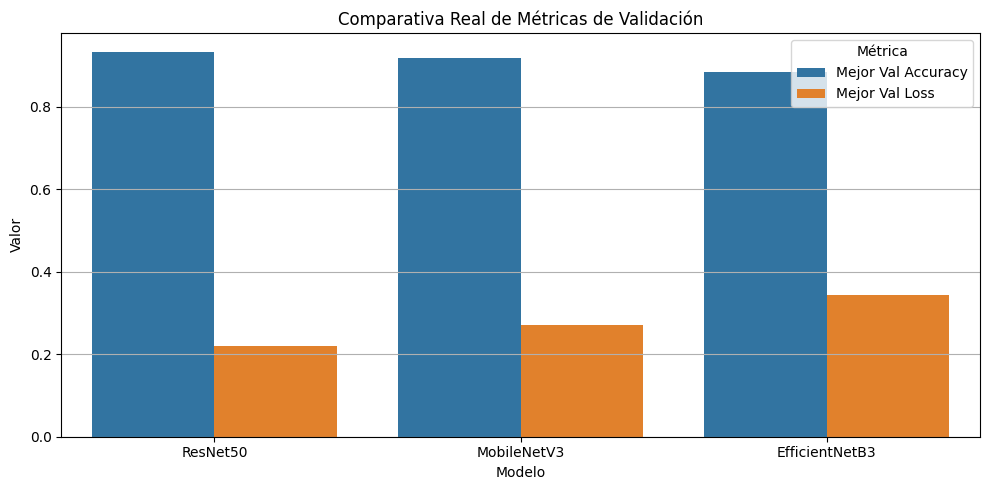

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_metricas.melt(
    id_vars="Modelo",
    value_vars=["Mejor Val Accuracy", "Mejor Val Loss"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparativa Real de Métricas de Validación")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Matriz de Confusión del Modelo de Autenticación de Partes**

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


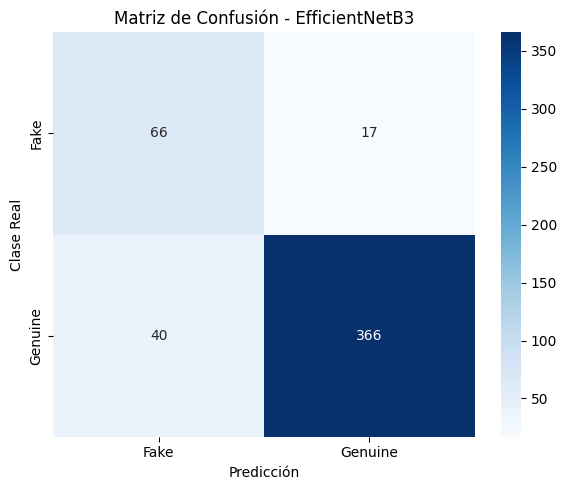


===== EfficientNetB3 =====
              precision    recall  f1-score   support

        Fake       0.62      0.80      0.70        83
     Genuine       0.96      0.90      0.93       406

    accuracy                           0.88       489
   macro avg       0.79      0.85      0.81       489
weighted avg       0.90      0.88      0.89       489



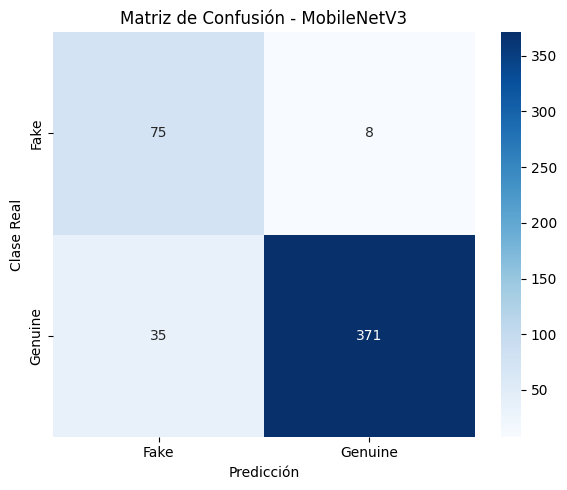


===== MobileNetV3 =====
              precision    recall  f1-score   support

        Fake       0.68      0.90      0.78        83
     Genuine       0.98      0.91      0.95       406

    accuracy                           0.91       489
   macro avg       0.83      0.91      0.86       489
weighted avg       0.93      0.91      0.92       489



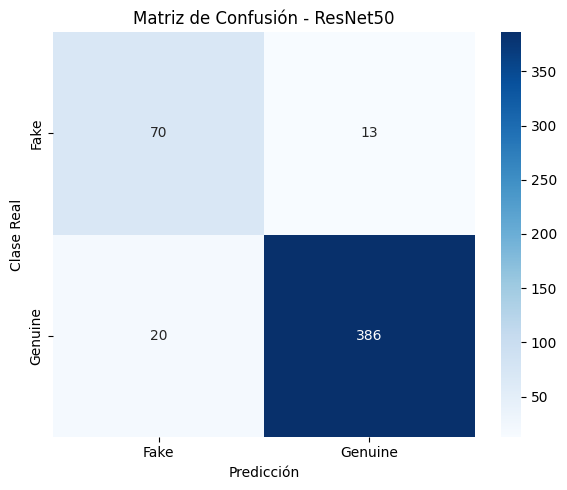


===== ResNet50 =====
              precision    recall  f1-score   support

        Fake       0.78      0.84      0.81        83
     Genuine       0.97      0.95      0.96       406

    accuracy                           0.93       489
   macro avg       0.87      0.90      0.88       489
weighted avg       0.94      0.93      0.93       489



In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

class_names = ['Fake', 'Genuine']

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

modelos = {
    "EfficientNetB3": (model_eff, val_ds_300),
    "MobileNetV3": (model_mobile, val_ds_224),
    "ResNet50": (model_resnet, val_ds_224)
}

for nombre, (modelo, dataset) in modelos.items():

    y_true = []
    y_prob = []

    for x_batch, y_batch in dataset:
        pred = modelo.predict(x_batch, verbose=0)
        y_prob.extend(pred.ravel())
        y_true.extend(y_batch.numpy().ravel())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Clase Real')
    plt.tight_layout()
    plt.show()

    print(f'\n===== {nombre} =====')
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

**K-Fold Cross Validation del Umbral Global**

Found 2446 files belonging to 2 classes.
Using 489 files for validation.
Found 2446 files belonging to 2 classes.
Using 489 files for validation.


,Modelo,Fold,Mejor Umbral,Accuracy,Precision,Recall,F1-Score
0,EfficientNetB3,1,0.65,0.795918,1.000000,0.756098,0.861111
1,EfficientNetB3,2,0.75,0.683673,1.000000,0.617284,0.763359
2,EfficientNetB3,3,0.62,0.846939,1.000000,0.814815,0.897959
3,EfficientNetB3,4,0.67,0.775510,1.000000,0.728395,0.842857
4,EfficientNetB3,5,0.57,0.824742,0.970588,0.814815,0.885906
5,MobileNetV3,1,0.50,0.918367,0.986842,0.914634,0.949367
6,MobileNetV3,2,0.56,0.877551,0.985915,0.864198,0.921053
7,MobileNetV3,3,0.50,0.959184,1.000000,0.950617,0.974684
8,MobileNetV3,4,0.50,0.948980,0.987179,0.950617,0.968553
9,MobileNetV3,5,0.62,0.783505,0.968750,0.765432,0.855172


Mejor Umbral                   Accuracy Precision    Recall  \
                       mean median       std      mean      mean      mean   
Modelo                                                                       
EfficientNetB3        0.652   0.65  0.066483  0.785357  0.994118  0.746281   
MobileNetV3           0.536   0.50  0.053666  0.897517  0.985737  0.889100   
ResNet50              0.636   0.63  0.137949  0.897559  0.989702  0.886540   

                F1-Score  
                    mean  
Modelo                    
EfficientNetB3  0.850238  
MobileNetV3     0.933766  
ResNet50        0.933656

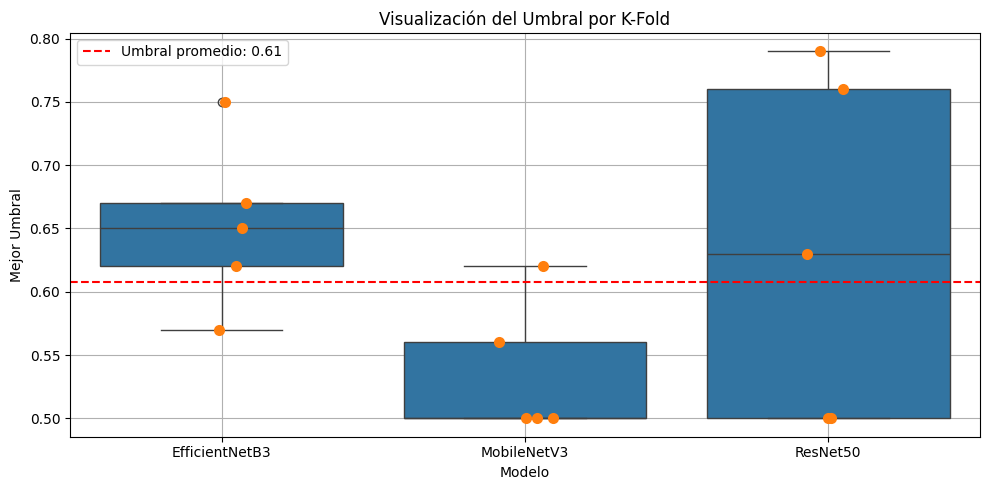

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

DATA_DIR = "/content/Chanel_Parts"
BATCH_SIZE = 16

val_ds_224 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=BATCH_SIZE
)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(300, 300),
    batch_size=BATCH_SIZE
)

val_ds_224 = val_ds_224.prefetch(tf.data.AUTOTUNE)
val_ds_300 = val_ds_300.prefetch(tf.data.AUTOTUNE)

modelos = {
    "EfficientNetB3": (model_eff, val_ds_300),
    "MobileNetV3": (model_mobile, val_ds_224),
    "ResNet50": (model_resnet, val_ds_224)
}

umbrales = np.arange(0.50, 0.96, 0.01)

resultados = []

for nombre, (modelo, dataset) in modelos.items():

    y_true = []
    y_prob = []

    for x_batch, y_batch in dataset:
        pred = modelo.predict(x_batch, verbose=0)
        y_prob.extend(pred.ravel())
        y_true.extend(y_batch.numpy().ravel())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for fold, (_, test_idx) in enumerate(
        skf.split(y_prob, y_true),
        start=1
    ):

        y_true_fold = y_true[test_idx]
        y_prob_fold = y_prob[test_idx]

        mejor_score = -1
        mejor_umbral = 0
        mejor_accuracy = 0
        mejor_precision = 0
        mejor_recall = 0
        mejor_f1 = 0

        for umbral in umbrales:

            y_pred_fold = (y_prob_fold >= umbral).astype(int)

            accuracy = accuracy_score(y_true_fold, y_pred_fold)

            precision = precision_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            recall = recall_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            f1 = f1_score(
                y_true_fold,
                y_pred_fold,
                zero_division=0
            )

            score = (0.90 * precision) + (0.10 * recall)

            if score > mejor_score:
                mejor_score = score
                mejor_umbral = umbral
                mejor_accuracy = accuracy
                mejor_precision = precision
                mejor_recall = recall
                mejor_f1 = f1

        resultados.append([
            nombre,
            fold,
            round(mejor_umbral, 2),
            mejor_accuracy,
            mejor_precision,
            mejor_recall,
            mejor_f1
        ])

df_kfold = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "Fold",
        "Mejor Umbral",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

display(df_kfold)

resumen = (
    df_kfold
    .groupby("Modelo")
    .agg({
        "Mejor Umbral": ["mean", "median", "std"],
        "Accuracy": "mean",
        "Precision": "mean",
        "Recall": "mean",
        "F1-Score": "mean"
    })
)

display(resumen)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_kfold,
    x="Modelo",
    y="Mejor Umbral"
)

sns.stripplot(
    data=df_kfold,
    x="Modelo",
    y="Mejor Umbral",
    size=8,
    jitter=True
)

plt.axhline(
    df_kfold["Mejor Umbral"].mean(),
    color="red",
    linestyle="--",
    label=f'Umbral promedio: {df_kfold["Mejor Umbral"].mean():.2f}'
)

plt.title("Visualización del Umbral por K-Fold")
plt.xlabel("Modelo")
plt.ylabel("Mejor Umbral")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()